# BEIP — EDA 03: Census 2011 Demographics Analysis

**Objective:** Explore district-level demographics from `silver.census_demographics` and connect them to electoral patterns:
- District and state coverage in Census 2011
- Geographic distribution of literacy rates
- Demographic indicators: Sex ratio, SC/ST population concentrations, worker participation
- Cross-dataset correlation: Relationship between state-level literacy and voter turnout

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.config import get_engine

engine = get_engine()
census = pd.read_sql("SELECT * FROM silver.census_demographics", engine)
print(f"Loaded {len(census):,} district records across {census['state_name'].nunique()} states/UTs.")

Loaded 1,908 district records across 35 states/UTs.


## 2. Basic Dataset Overview & Quality Checks

In [2]:
census.head()

,state_name,district_name,total_population,male_population,female_population,literacy_rate,sex_ratio,sc_percentage,st_percentage,worker_participation
0,Jammu And Kashmir,Kupwara,870354,474190,396164,50.51,835.45,0.12,8.08,26.32
1,Jammu And Kashmir,Kupwara,765625,412038,353587,48.98,858.14,0.11,8.95,25.60
2,Jammu And Kashmir,Kupwara,104729,62152,42577,61.74,685.05,0.17,1.78,31.58
3,Jammu And Kashmir,Badgam,753745,398041,355704,44.53,893.64,0.05,3.17,28.51
4,Jammu And Kashmir,Badgam,655833,343385,312448,42.43,909.91,0.01,3.55,27.72


In [3]:
print("=== Missing Values in Census Data ===")
print(census.isnull().sum())

print("\n=== Summary Statistics ===")
census.describe()

=== Missing Values in Census Data ===
state_name              0
district_name           0
total_population        0
male_population         0
female_population       0
literacy_rate           0
sex_ratio               0
sc_percentage           0
st_percentage           0
worker_participation    0
dtype: int64

=== Summary Statistics ===


,total_population,male_population,female_population,literacy_rate,sex_ratio,sc_percentage,st_percentage,worker_participation
count,1.908000e+03,1.908000e+03,1.908000e+03,1908.000000,1908.000000,1908.000000,1908.000000,1908.000000
mean,1.269240e+06,6.533231e+05,6.159169e+05,64.861279,940.666903,14.304916,15.886473,39.604256
std,1.318101e+06,6.828491e+05,6.362098e+05,11.129517,65.382491,9.014113,26.149468,7.742686
min,9.820000e+02,6.250000e+02,3.570000e+02,25.420000,340.110000,0.000000,0.000000,24.420000
25%,2.834090e+05,1.467335e+05,1.360288e+05,57.007500,902.212500,7.670000,0.330000,33.540000
50%,9.257840e+05,4.744960e+05,4.493345e+05,65.840000,943.495000,14.510000,3.220000,37.910000
75%,1.750198e+06,8.999940e+05,8.469390e+05,73.447500,979.952500,20.040000,16.637500,45.352500
max,1.106015e+07,5.865078e+06,5.195070e+06,89.050000,1184.400000,53.390000,98.930000,72.180000


## 3. Literacy Rate Analysis
Examine literacy rate variation across states and district-level distribution.

C:\Users\chris\AppData\Local\Temp\ipykernel_3284\321552753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_lit, x="literacy_rate", y="state_name", palette="Blues_r")


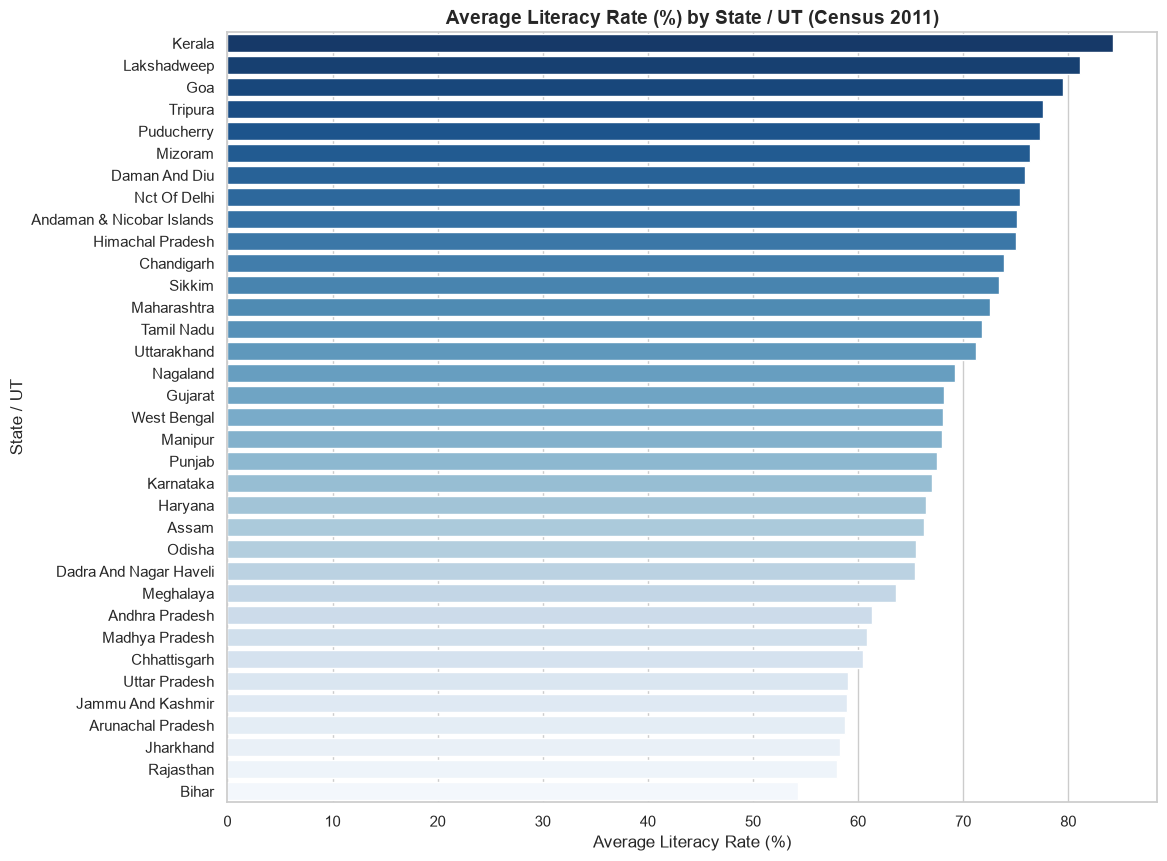

Top 5 States by Literacy Rate:


,state_name,literacy_rate
16,Kerala,84.265476
17,Lakshadweep,81.106667
9,Goa,79.491667
31,Tripura,77.575000
26,Puducherry,77.339000


Bottom 5 States by Literacy Rate:


,state_name,literacy_rate
13,Jammu And Kashmir,58.960606
2,Arunachal Pradesh,58.728958
14,Jharkhand,58.268472
28,Rajasthan,57.977172
4,Bihar,54.243509


In [4]:
# State-level average literacy rate
state_lit = census.groupby("state_name")["literacy_rate"].mean().reset_index()
state_lit = state_lit.dropna().sort_values("literacy_rate", ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=state_lit, x="literacy_rate", y="state_name", palette="Blues_r")
plt.title("Average Literacy Rate (%) by State / UT (Census 2011)", fontsize=14, fontweight="bold")
plt.xlabel("Average Literacy Rate (%)")
plt.ylabel("State / UT")
plt.show()

print("Top 5 States by Literacy Rate:")
display(state_lit.head(5))
print("Bottom 5 States by Literacy Rate:")
display(state_lit.tail(5))

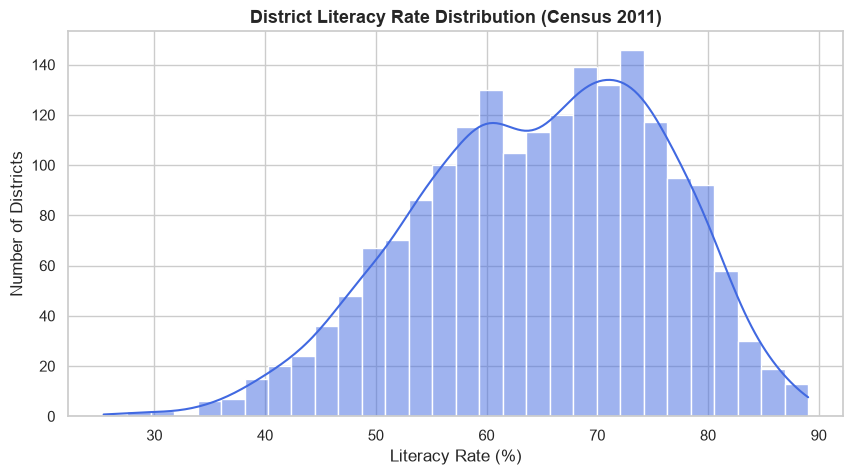

In [5]:
# District Literacy Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=census, x="literacy_rate", bins=30, kde=True, color="royalblue")
plt.title("District Literacy Rate Distribution (Census 2011)", fontsize=13, fontweight="bold")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Number of Districts")
plt.show()

## 4. Demographic Metrics (Sex Ratio & SC/ST Distribution)
Analyze sex ratios and demographic composition across regions.

C:\Users\chris\AppData\Local\Temp\ipykernel_3284\2785806777.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_demo.sort_values("avg_sex_ratio", ascending=False), x="avg_sex_ratio", y="state_name", palette="Purples_r")


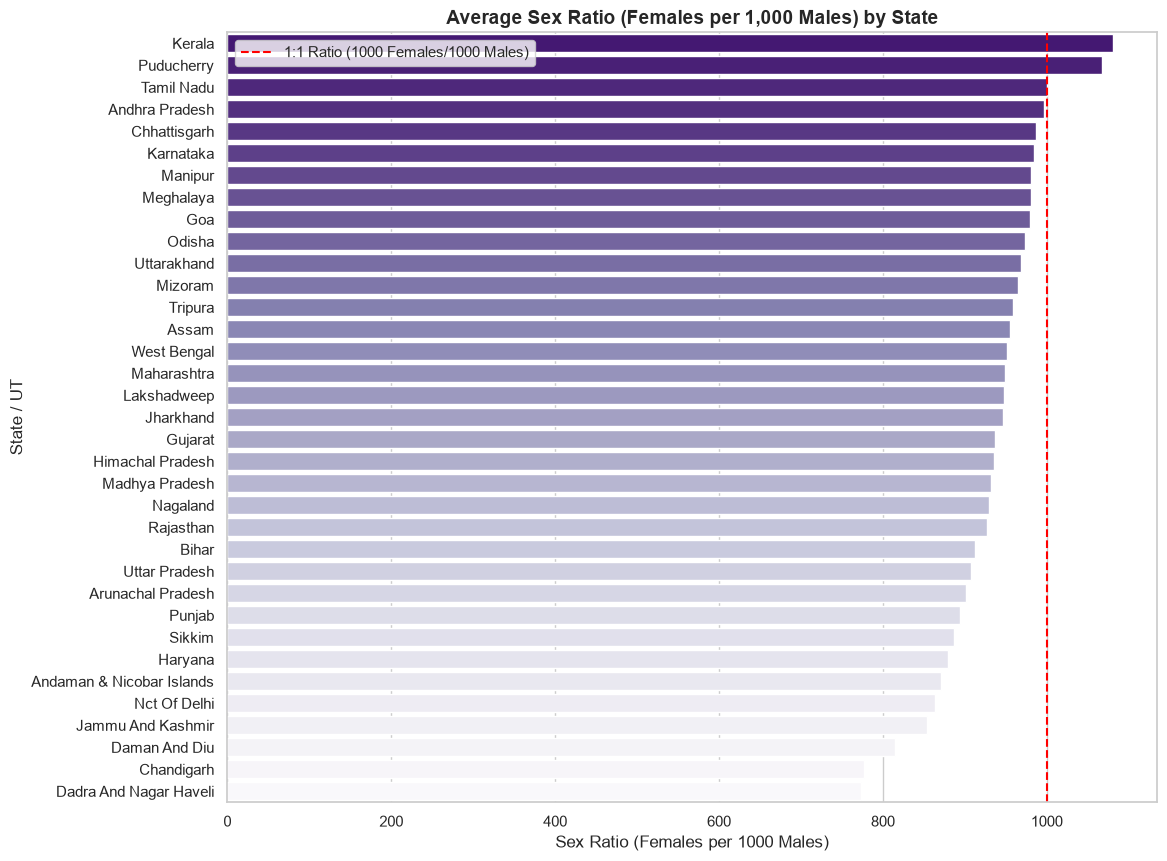

In [6]:
state_demo = census.groupby("state_name").agg(
    avg_sex_ratio=("sex_ratio", "mean"),
    avg_sc_pct=("sc_percentage", "mean"),
    avg_st_pct=("st_percentage", "mean"),
    avg_worker_part=("worker_participation", "mean")
).reset_index()

plt.figure(figsize=(12, 10))
sns.barplot(data=state_demo.sort_values("avg_sex_ratio", ascending=False), x="avg_sex_ratio", y="state_name", palette="Purples_r")
plt.axvline(1000, color="red", linestyle="--", label="1:1 Ratio (1000 Females/1000 Males)")
plt.title("Average Sex Ratio (Females per 1,000 Males) by State", fontsize=14, fontweight="bold")
plt.xlabel("Sex Ratio (Females per 1000 Males)")
plt.ylabel("State / UT")
plt.legend()
plt.show()

## 5. Cross-Dataset Analysis: Literacy Rate vs. Voter Turnout
Join state-level Census demographics with state voter turnout from `silver.election_results` to observe structural patterns.

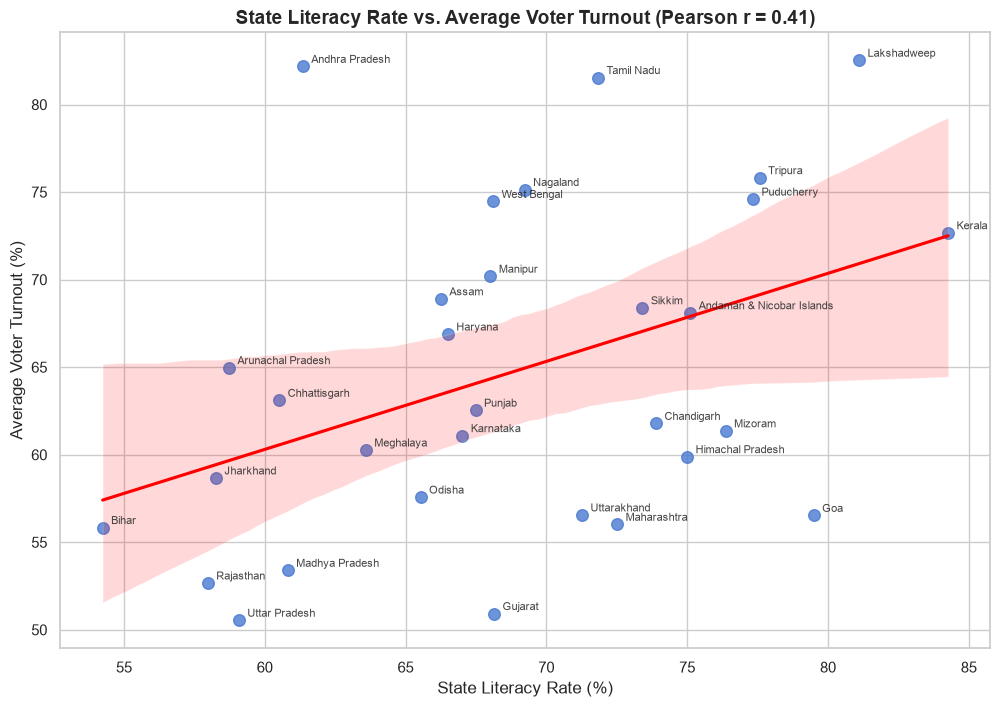

In [7]:
# Load election turnout by state
elections = pd.read_sql("""
    SELECT 
        state_name, 
        AVG(turnout_percentage) AS avg_turnout
    FROM silver.election_results
    GROUP BY state_name
""", engine)

# Merge with state census
combined = state_lit.merge(elections, on="state_name", how="inner")

plt.figure(figsize=(12, 8))
sns.regplot(data=combined, x="literacy_rate", y="avg_turnout", scatter_kws={"s": 70, "alpha": 0.8}, line_kws={"color": "red"})

# Annotate points with state names
for _, row in combined.iterrows():
    plt.text(row["literacy_rate"] + 0.3, row["avg_turnout"] + 0.2, row["state_name"], fontsize=8, alpha=0.85)

corr_val = combined["literacy_rate"].corr(combined["avg_turnout"])
plt.title(f"State Literacy Rate vs. Average Voter Turnout (Pearson r = {corr_val:.2f})", fontsize=14, fontweight="bold")
plt.xlabel("State Literacy Rate (%)")
plt.ylabel("Average Voter Turnout (%)")
plt.show()